In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.01 # In [fm^-2]
ENDING_RANGE_PARAMETER = 2500
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 50 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30 * 1)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [2]:
def single_particle_overlap(range_parameter_i, range_parameter_j):
    return ((2 * range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5)

def single_particle_potential_element(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)
    return V_0 * (term_1 * term_2)**(1.5)

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, μ=REDUCED_MASS):
    term_1 = range_parameter_i**2 + range_parameter_j**2
    return (197**2 / (2 * μ)) * 6 * single_particle_overlap(range_parameter_i, range_parameter_j) / term_1

def super_symmetric_potential_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                      central_potential_param, k_value, μ=REDUCED_MASS):
    """
    Supersymmetric potential that removes the bound 1s groundstate
    associated with the neutrons in the He-4 core.
    """
    core_neutron_potential =  potential_matrix_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                                       central_potential_param)
    alpha_k = 1 / next_range_parameter(k_value)**0.5
    super_symmetry_term = 2 * (197**2 / μ) * alpha_k**(-2) *  overlap_matrix_element(range_param_i, range_param_j)
    return core_neutron_potential + super_symmetry_term

In [3]:
def matrix_generation(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix

def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

#theta = 5 * np.pi / 36 
#s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, theta)
#p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, theta)
#p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, theta)
#d_five_half_h_matrix, d_five_half_n_matrix = matrix_generation(2.5, 2, theta)

In [16]:
s_h_matrix, s_n_matrix = matrix_generation()
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
s2_eigenvector = np.asmatrix(s_eigenvectors[:, 2])
s3_eigenvector = np.asmatrix(s_eigenvectors[:, 3])
print("The S state eigenvalues are", s_eigenvalues)
print("The S0 eigenvector is", s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 12036649.784645967
The S state eigenvalues are [-3.97191215e+01 -2.92477506e-01  7.15662439e-06  3.03232993e-05
  7.51402148e-05  1.52905904e-04  2.83768491e-04  5.02195486e-04
  8.66271992e-04  1.47349605e-03  2.48760127e-03  4.18422454e-03
  7.02903320e-03  1.18123472e-02  1.98827583e-02  3.35558253e-02
  5.68315933e-02  9.66558906e-02  1.65117524e-01  2.83258444e-01
  4.87664680e-01  8.42183353e-01  1.45914127e+00  2.53907999e+00
  4.44453029e+00  7.83851199e+00  1.39216904e+01  2.48192569e+01
  4.41952073e+01  7.81939820e+01  1.37571243e+02  2.41423818e+02
  4.21754039e+02  7.30281938e+02  1.25121374e+03  2.12349030e+03
  3.57770298e+03  5.99713705e+03  1.00190910e+04  1.67035377e+04
  2.78146854e+04  4.62929323e+04  7.70513451e+04  1.28335552e+05
  2.14092650e+05  3.58242803e+05  6.02853802e+05  1.02548712e+06
  1.78350433e+06  3.27862130e+06]
The S0 eigenvector is [[-4.27791907e-09  2.46103892e-08 -7.84680006e-08  1.89135790e-07
  -3.9

Ground state wavefunction has overlap 0.9999999999999987 with itself


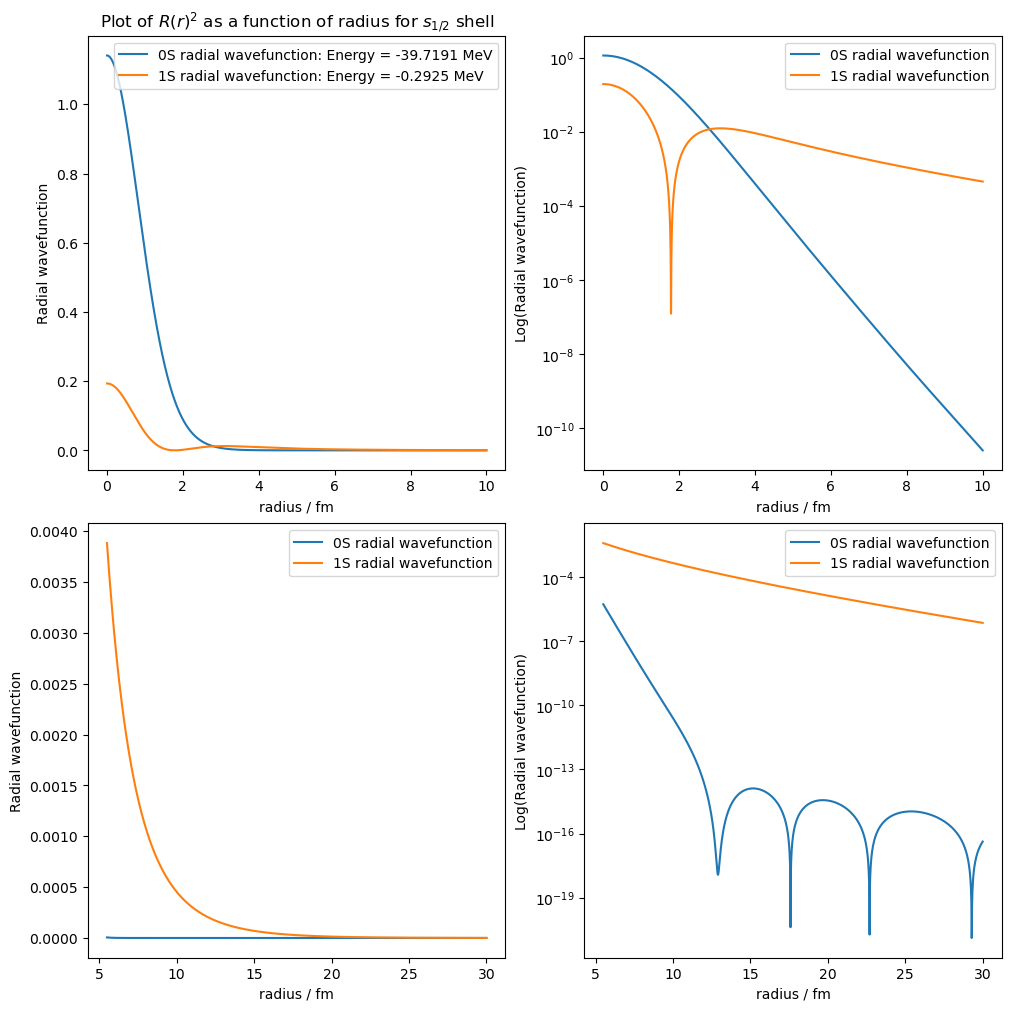

In [5]:
def wavefunction_overlap(orb_ang_momentum_i, orb_ang_momentum_j, i_mixing_coefficients, j_mixing_coefficients, overlap_matrix=None, size=SUM_LIMIT):
    try:
        _ = overlap_matrix.shape
        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
    except AttributeError:
        overlap_matrix = np.zeros(shape=(size, size))

        for i in range(size):
            i_range_parameter = next_range_parameter(i)
            for j in range(size):
                j_range_parameter = next_range_parameter(j)
                overlap_matrix[i, j] = different_l_overlap_matrix_element(orb_ang_momentum_i, orb_ang_momentum_j, i_range_parameter, j_range_parameter)

        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
print(f'Ground state wavefunction has overlap {wavefunction_overlap(0, 0, s0_eigenvector, s0_eigenvector, overlap_matrix=s_n_matrix)} with itself')

def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunction_eigenvector[0, j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(5.5, 30, 3000)

fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])
ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, s0_eigenvector, 0),
          label=f"0S radial wavefunction: Energy = {s_eigenvalues[0]:.4f} MeV")
ax_1.plot(x_values, radial_wavefunction(x_values, s1_eigenvector, 0),
          label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
#ax_1.plot(x_values, radial_wavefunction(x_values, s2_eigenvector, 0),
#          label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
#ax_1.plot(x_values, radial_wavefunction(x_values, s3_eigenvector, 0),
#          label=f"3S radial wavefunction: Energy = {s_eigenvalues[3]:.4f} MeV", c='k')
ax_1.legend()

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_2.semilogy(x_values, radial_wavefunction(x_values, s1_eigenvector, 0), label="1S radial wavefunction")
#ax_2.semilogy(x_values, radial_wavefunction(x_values, s2_eigenvector, 0), label="2S radial wavefunction")
#ax_2.semilogy(x_values, radial_wavefunction(x_values, s3_eigenvector, 0), label="3S radial wavefunction", c='k')
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s1_eigenvector, 0), label="1S radial wavefunction")
#ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s2_eigenvector, 0), label="2S radial wavefunction")
#ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s3_eigenvector, 0), label="3S radial wavefunction", c='k')
ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s1_eigenvector, 0), label="1S radial wavefunction")
#ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s2_eigenvector, 0), label="2S radial wavefunction")
#ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s3_eigenvector, 0), label="3S radial wavefunction", c='k')
ax_4.legend()



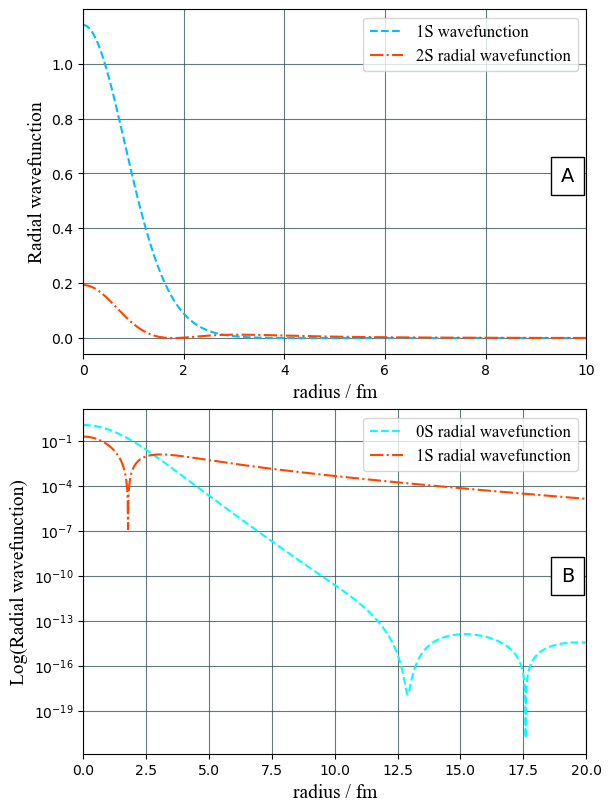

In [37]:
font_size_variable = 14
tick_size_variable = 10
legend_font = font_manager.FontProperties(family='Times New Roman',
                                          style='normal', size=12)

r_values = np.linspace(0, 10, 3000)
r_values_2 = np.linspace(0, 20, 3000)

fig = plt.figure(figsize=(6, 8), layout='constrained')
spec = fig.add_gridspec(ncols=1, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[1,0])

ax_1.set_xlabel('radius / fm', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_ylabel('Radial wavefunction', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_xlim(left=0, right=10)
ax_1.plot(r_values, radial_wavefunction(r_values, s0_eigenvector, 0), linestyle='--', c='deepskyblue',
          label="1S wavefunction")
ax_1.plot(r_values, radial_wavefunction(r_values, s1_eigenvector, 0), linestyle='-.', c='orangered',
          label="2S radial wavefunction")
ax_1.annotate('A', xy=(0.95, 0.5), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_1.grid(color='darkslategrey', alpha=0.75)
#, dashes=[6, 3, 6, 3]
ax_1.legend(prop=legend_font)

ax_2.set_xlabel('radius / fm', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_ylabel('Log(Radial wavefunction)', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_xlim(left=0, right=20)
ax_2.semilogy(r_values_2, radial_wavefunction(r_values_2, s0_eigenvector, 0), linestyle='--', c='cyan',
              label="0S radial wavefunction")
ax_2.semilogy(r_values_2, radial_wavefunction(r_values_2, s1_eigenvector, 0), linestyle='-.', c='orangered',
              label="1S radial wavefunction")
ax_2.annotate('B', xy=(0.95, 0.5), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_2.grid(color='darkslategrey', alpha=0.75)
ax_2.legend(prop=legend_font)

plt.savefig('Inital_Wavefunction_plot.png')

In [7]:
def position_operator_matrix_element(orb_ang_momentum, range_param_i, range_param_j):
    term_1 = 2**(1.5 + orb_ang_momentum) * 0.5 * (3 + 2 * orb_ang_momentum)
    term_2 = (range_param_i * range_param_j)**(3.5 + orb_ang_momentum)
    term_3 = (range_param_i**2 + range_param_j**2)**(-2.5 - orb_ang_momentum)
    return term_1 * term_2 * term_3 

def poisition_operator(orb_ang_momentum, state_eigenvector, size=SUM_LIMIT):
    average_radius = 0
    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            average_radius += state_eigenvector[0, i] * state_eigenvector[0, j] * position_operator_matrix_element(
                orb_ang_momentum, i_range_parameter, j_range_parameter)
    return average_radius

S1_rms_radius = poisition_operator(0, s1_eigenvector)**0.5
print(S1_rms_radius)


8.76887904347606


C:\Users\faola\AppData\Local\Temp\ipykernel_20356\3392196175.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]
C:\Users\faola\AppData\Local\Temp\ipykernel_20356\3392196175.py:31: RuntimeWarning: invalid value encountered in scalar multiply
  -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]


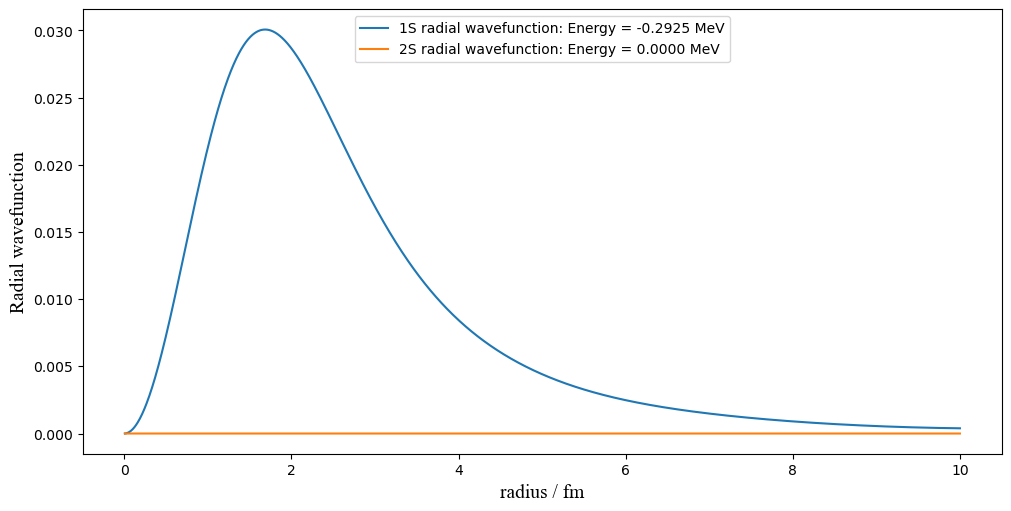

In [8]:
def susy_transformed_wavefunc(radius, inital_wavefunc_eigenvector, inital_wavefunc_energy, gs_eigenvector,
                              gs_energy, sum_limit=SUM_LIMIT):
    differentiated_wavefunction_vals = np.zeros(shape=(len(radius),))
    superpotential_vals_1 = np.zeros(shape=(len(radius),))
    superpotential_vals_2 = np.zeros(shape=(len(radius),))
    inital_wavefunction_vals = np.zeros(shape=(len(radius),))
    wavefunction_vals = np.zeros(shape=(len(radius),))

    def reduced_gaussian_wavefunction(radius, range_parameter):
        normalisation = (2**(-2.5) * (range_parameter)**(3) * gamma(1.5))**(-0.5)
        return normalisation * radius * np.exp(-(radius / range_parameter)**2)

    def reduced_diffentiated_gaussian_wavefunction(radius, range_parameter):
        normalisation = (2**(-2.5) * (range_parameter)**(3) * gamma(1.5))**(-0.5)
        return normalisation * (1 - 2 * (radius**2 / range_parameter**2)) * np.exp(-(radius / range_parameter)**2)

    susy_normalisation = (inital_wavefunc_energy - gs_energy)**(-0.5)

    for i in range(len(radius)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            inital_wavefunction_vals[i] += (inital_wavefunc_eigenvector[0, j] * reduced_gaussian_wavefunction(radius[i], 
                range_parameter))
            differentiated_wavefunction_vals[i] += (inital_wavefunc_eigenvector[0, j] * reduced_diffentiated_gaussian_wavefunction(radius[i], 
                range_parameter))
            superpotential_vals_1[i] += (gs_eigenvector[0, j] * reduced_diffentiated_gaussian_wavefunction(radius[i], 
                range_parameter))
            superpotential_vals_2[i] += (gs_eigenvector[0, j] * reduced_gaussian_wavefunction(radius[i], 
                range_parameter))
        wavefunction_vals[i] = (197 / np.sqrt(2 * REDUCED_MASS)) * susy_normalisation * (
            -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]
                                                   ) * inital_wavefunction_vals[i]) / radius[i]
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals


x_values = np.linspace(0, 10, 1500)
susy_transformed_wavefunc

fig = plt.figure(figsize=(10, 5), layout='constrained')
#spec = fig.add_gridspec(ncols=2, nrows=1)
#fig.suptitle(r"Bound state wavefunctions transformed by $A^{-}$ using the groundstate wavefunction")
ax_1 = fig.add_subplot()
#ax_2 = fig.add_subplot(spec[0, 1])
ax_1.set_xlabel('radius / fm', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_ylabel('Radial wavefunction', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.plot(x_values, susy_transformed_wavefunc(x_values, s1_eigenvector, s_eigenvalues[1],
                                              s0_eigenvector, s_eigenvalues[0]),
          label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_1.plot(x_values, susy_transformed_wavefunc(x_values, s2_eigenvector, s_eigenvalues[2],
                                              s0_eigenvector, s_eigenvalues[0]),
          label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
ax_1.legend(loc='upper center')


#ax_2.plot(x_values, susy_transformed_wavefunc(x_values, s3_eigenvector, s_eigenvalues[3],
#                                              s0_eigenvector, s_eigenvalues[0]),
#          label=f"3S radial wavefunction: Energy = {s_eigenvalues[3]:.4f} MeV")
#ax_2.legend()



We want to quickly do a superpotential plot for a few other wavefuncs to see how they behave at nodes

In [13]:
NUM_SUSY_GAUSSIANS = 15
SUSY_POTENTIAL_PARAMS = [0.015625,0.0216263,0.0299326,0.0414292,0.0573414,0.0793653,0.109848,
                                   0.152039,0.210435,0.291259,0.403127,0.557961,0.772264,1.06888,1.47942]
SUSY_POTENTIAL_COEFFS = np.array([-33.7795,125.728,-214.962,195.943,-59.5447,-118.117,235.946,-253.234,305.881,-243.858,148.467,
                         -74.1628,29.1132,-7.90282,1.0961])
CENTRAL_POTENTIAL_STRENGTH = -47.32 * 2

def SUSY_single_particle_overlap(range_parameter_i, range_parameter_j, orbital_angular_momentum):
    term_1 = 2 * range_parameter_i * range_parameter_j
    term_2 = range_parameter_i**2 + range_parameter_j**2
    return (term_1 / term_2)**((5/2) + orbital_angular_momentum)

def SUSY_single_particle_potential_element(range_parameter_i, range_parameter_j, orbital_angular_momentum,
                                           mixing_coefficient, potential_strength, potential_param):
    """
    term_1 = 2 * range_parameter_i * range_parameter_j
    term_2 = range_parameter_i**2 + range_parameter_j**2 
    term_3 = range_parameter_i**2 * range_parameter_j**2 * potential_param
    return mixing_coefficient * potential_strength * (term_1 / (term_2 + term_3))**((5/2) + orbital_angular_momentum)
    """
    term_1 = (2 / (range_parameter_i * range_parameter_j))**(2.5 + orbital_angular_momentum)
    term_2 = (range_parameter_i**(-2) + range_parameter_j**(-2) + potential_param)**(2.5 + orbital_angular_momentum)
    return mixing_coefficient * potential_strength * term_1 / term_2

def SUSY_single_particle_kinetic_element(range_parameter_i, range_parameter_j, orbital_angular_momentum, μ=REDUCED_MASS):
    term_A = (2**((7/2) + orbital_angular_momentum)) / (3 + 2 * orbital_angular_momentum)

    term_1 = ((orbital_angular_momentum + 0) * (orbital_angular_momentum + 1)) / (range_parameter_i * range_parameter_j)
    term_2 = ((range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5 + orbital_angular_momentum)
    term_B = term_1 * term_2

    term_3 = (range_parameter_i * range_parameter_j)**(0.5 + orbital_angular_momentum)
    term_4 = (range_parameter_i**2 + range_parameter_j**2)**((7/2) + orbital_angular_momentum)
    term_5 = (orbital_angular_momentum + 1) * (orbital_angular_momentum + 2) * (range_parameter_i**4 + range_parameter_j**4)
    term_6 = (11 + 2 * orbital_angular_momentum * (5 + orbital_angular_momentum)) * range_parameter_i**2 * range_parameter_j**2
    term_C = (term_3 / term_4) * (term_5 - term_6)

    return (197**2 / (2 * μ)) * (term_A * (term_B - term_C))

def r_minus_two_element(range_parameter_i, range_parameter_j, orbital_angular_momentum, μ=REDUCED_MASS):
    term_1 = (2**((9/2) + orbital_angular_momentum)) / ((3 + 2 * orbital_angular_momentum) * range_parameter_i * range_parameter_j)
    term_2 = ((range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**((3/2) + orbital_angular_momentum)
    return (197**2 / (2 * μ)) * term_1 * term_2

def susy_matrix_generation(orbital_angular_momentum, 
                      central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      susy_potential_mixing_coefficients=SUSY_POTENTIAL_COEFFS,
                      susy_potential_parameters=SUSY_POTENTIAL_PARAMS,
                      centeral_potential_strength=CENTRAL_POTENTIAL_STRENGTH,
                      size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = SUSY_single_particle_kinetic_element(i_range_parameter, j_range_parameter,
                                                                       orbital_angular_momentum)
            additional_susy_term = r_minus_two_element(i_range_parameter, j_range_parameter, orbital_angular_momentum)
            potential_energy_term = 0
            susy_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += SUSY_single_particle_potential_element(
                    i_range_parameter, j_range_parameter, orbital_angular_momentum,
                    central_mixing_coefficients[k], centeral_potential_strength,
                    central_potential_parameters[k])
            for k in range(len(susy_potential_mixing_coefficients)):
                susy_energy_term += SUSY_single_particle_potential_element(
                    i_range_parameter, j_range_parameter, orbital_angular_momentum,
                    susy_potential_mixing_coefficients[k], 1,
                    susy_potential_parameters[k])
            h_matrix[i, j] = (kinetic_energy_term + potential_energy_term + susy_energy_term + additional_susy_term)
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = SUSY_single_particle_overlap(i_range_parameter, j_range_parameter, orbital_angular_momentum)

    return h_matrix, n_matrix

In [15]:
susy_s_h_matrix, susy_s_n_matrix = susy_matrix_generation(0)
susy_s_eigenvalues, susy_s_eigenvectors = scipy.linalg.eigh(susy_s_h_matrix, susy_s_n_matrix)
susy_s_overlap_eigenvalues, susy_s_overlap_eigenvectors = scipy.linalg.eigh(susy_s_n_matrix)
susy_s_overlap_matrix_condition_number = np.max(susy_s_overlap_eigenvalues) / np.min(susy_s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is {susy_s_overlap_matrix_condition_number:e}")

susy_s0_eigenvector = np.asmatrix(susy_s_eigenvectors[:, 0])
susy_s1_eigenvector = np.asmatrix(susy_s_eigenvectors[:, 1])
susy_s2_eigenvector = np.asmatrix(susy_s_eigenvectors[:, 2])
print("The S state eigenvalues are", susy_s_eigenvalues)

The s 1/2 overlap matrix condition number is 1.089019e+06
The S state eigenvalues are [-2.92744667e-01  1.34358454e-05  4.27252689e-05  9.50944002e-05
  1.83515651e-04  3.30534661e-04  5.74231786e-04  9.78207119e-04
  1.64827133e-03  2.76026638e-03  4.60634264e-03  7.67203023e-03
  1.27644754e-02  2.12271414e-02  3.52969117e-02  5.87052512e-02
  9.76424560e-02  1.62327178e-01  2.69264984e-01  4.46235669e-01
  7.43916546e-01  1.26143490e+00  2.16656036e+00  3.70665337e+00
  6.37698340e+00  1.10739112e+01  1.92775097e+01  3.35250537e+01
  5.81039464e+01  1.00284487e+02  1.72414613e+02  2.95462072e+02
  5.04340278e+02  8.56411664e+02  1.44611216e+03  2.42973585e+03
  4.06670825e+03  6.78806239e+03  1.13101752e+04  1.88240169e+04
  3.13107417e+04  5.20697605e+04  8.66075953e+04  1.44149751e+05
  2.40260542e+05  4.01534719e+05  6.74501950e+05  1.14435815e+06
  1.98245634e+06  3.62192811e+06]


C:\Users\faola\AppData\Local\Temp\ipykernel_20356\3392196175.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]
C:\Users\faola\AppData\Local\Temp\ipykernel_20356\3392196175.py:31: RuntimeWarning: invalid value encountered in scalar multiply
  -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]


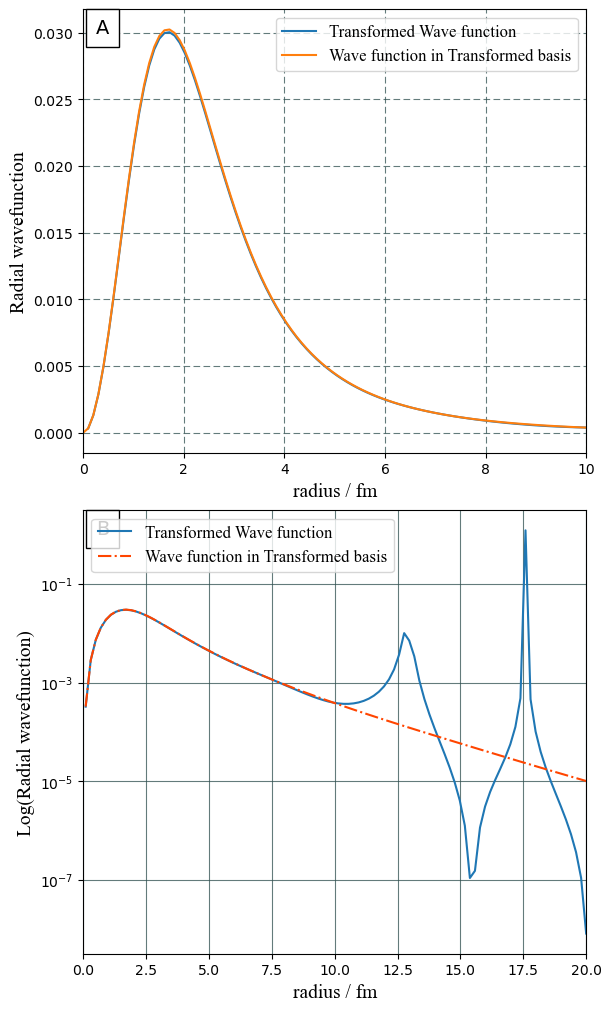

In [35]:
x_values = np.linspace(0, 10, 100)
x_values_2 = np.linspace(0.1, 20, 100)

fig = plt.figure(figsize=(6, 10), layout='constrained')
spec = fig.add_gridspec(ncols=1, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[1,0])

ax_1.set_xlabel('radius / fm', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_ylabel('Radial wavefunction', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_xlim(left=0, right=10)
ax_1.plot(x_values, susy_transformed_wavefunc(x_values, s1_eigenvector, s_eigenvalues[1],
                                              s0_eigenvector, s_eigenvalues[0]),
          label="Transformed Wave function")
ax_1.plot(x_values, radial_wavefunction(x_values, susy_s0_eigenvector, 1),
          label="Wave function in Transformed basis")
#ax_1.legend(loc='upper center')
ax_1.legend(prop=legend_font)
ax_1.annotate('A', xy=(0.025, 0.945), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_1.grid(color='darkslategrey', dashes=[6, 3, 6, 3], alpha=0.75)

ax_2.set_xlabel('radius / fm', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_ylabel('Log(Radial wavefunction)', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_xlim(left=0, right=20)
ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values_2, np.abs(susy_transformed_wavefunc(
    x_values_2, s1_eigenvector, s_eigenvalues[1], s0_eigenvector, s_eigenvalues[0])), 
              label="Transformed Wave function")
ax_2.semilogy(x_values_2, np.abs(radial_wavefunction(x_values_2, susy_s0_eigenvector, 1)),
              label="Wave function in Transformed basis", linestyle='-.', c='orangered')
ax_2.annotate('B', xy=(0.025, 0.945), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_2.grid(color='darkslategrey', alpha=0.75)
ax_2.legend(prop=legend_font)

plt.savefig('SUSY_wavefunction_plots.png')